In [68]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score,confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

In [70]:
# Paths to the CSV and images directory
train_csv_path = '/Users/sandipkumarsahoo/Downloads/aptos2019-blindness-detection/train.csv'
train_images_path = '/Users/sandipkumarsahoo/Downloads/aptos2019-blindness-detection/train_images'


In [72]:
# Load the training data CSV into a DataFrame
train_df = pd.read_csv(train_csv_path)
train_df['id_code'] = train_df['id_code'] + '.png'  # Add .png extension to the image IDs

# Convert 'diagnosis' column to strings for binary classification
# Assuming you want to classify as '0' (no disease) vs '1' (any level of disease)
train_df['diagnosis'] = train_df['diagnosis'].apply(lambda x: '1' if x > 0 else '0')


In [74]:
# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,  # Normalize pixel values between 0 and 1
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # Use 20% of data for validation
)

In [76]:
# Training data generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=train_images_path,
    x_col='id_code',
    y_col='diagnosis',
    subset='training',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'  # Use 'binary' for two classes (e.g., Disease/No Disease)
)

Found 2930 validated image filenames belonging to 2 classes.


In [78]:
# Validation data generator
validation_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=train_images_path,
    x_col='id_code',
    y_col='diagnosis',
    subset='validation',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 732 validated image filenames belonging to 2 classes.


In [80]:
# Model Architecture
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Summary of the model
model.summary()

# Train the model with error handling
try:
    history = model.fit(
        train_generator,
        steps_per_epoch=len(train_generator),
        epochs=20,
        validation_data=validation_generator,
        validation_steps=len(validation_generator),
        verbose=1
    )
except Exception as e:
    print(f"An error occurred during training: {e}")

# Save the trained model to a file
model.save('diabetic_retinopathy_cnn.keras')

# Evaluate the model on validation data
accuracy = model.evaluate(validation_generator)[1]
print(f'Validation Accuracy: {accuracy * 100:.2f}%')


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

...

92/92 ━━━━━━━━━━━━━━━━━━━━ 233s 3s/step - accuracy: 0.9100 - loss: 0.2685 - val_accuracy: 0.9044 - val_loss: 0.2394
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 200us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 231s 3s/step - accuracy: 0.9103 - loss: 0.2437 - val_accuracy: 0.9139 - val_loss: 0.2076
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 70us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 9/20


2025-04-20 16:29:56.802164: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


92/92 ━━━━━━━━━━━━━━━━━━━━ 234s 3s/step - accuracy: 0.9249 - loss: 0.2362 - val_accuracy: 0.8921 - val_loss: 0.2484
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 81us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 230s 3s/step - accuracy: 0.9171 - loss: 0.2362 - val_accuracy: 0.9221 - val_loss: 0.2323
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 75us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 13/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.9330 - loss: 0.2131 - val_accuracy: 0.9194 - val_loss: 0.2079
Epoch 14/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 72us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 15/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 232s 3s/step - accuracy: 0.9323 - loss: 0.2035 - val_accuracy: 0.9153 - val_loss: 0.2418
Epoch 16/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 200us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 17/20


2025-04-20 16:45:24.852599: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


92/92 ━━━━━━━━━━━━━━━━━━━━ 234s 3s/step - accuracy: 0.9330 - loss: 0.2037 - val_accuracy: 0.9235 - val_loss: 0.1988
Epoch 18/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 264us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 19/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 230s 3s/step - accuracy: 0.9354 - loss: 0.1974 - val_accuracy: 0.9276 - val_loss: 0.2005
Epoch 20/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 318us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
23/23 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9459 - loss: 0.1735
Validation Accuracy: 93.44%


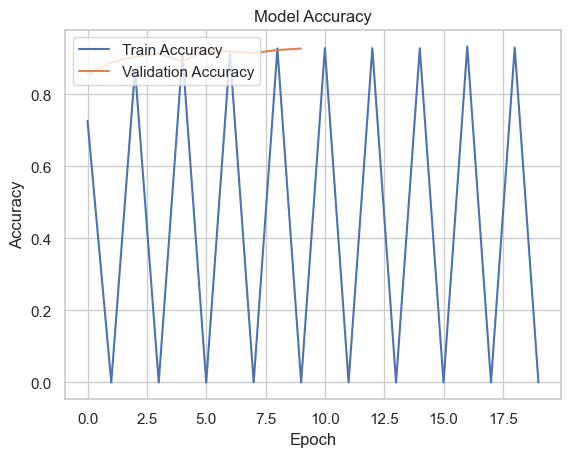

In [86]:
# Visualize training history
# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()


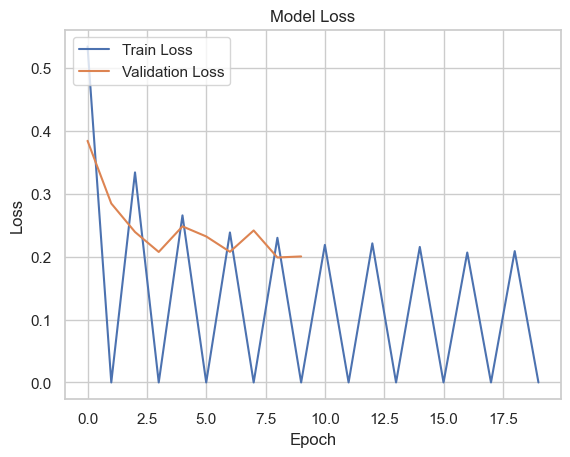

In [88]:
# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

/var/folders/2k/46dv5zj97cb0nhjw799hgpc40000gn/T/ipykernel_6969/2101224224.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=models, y=accuracies, palette=colors)


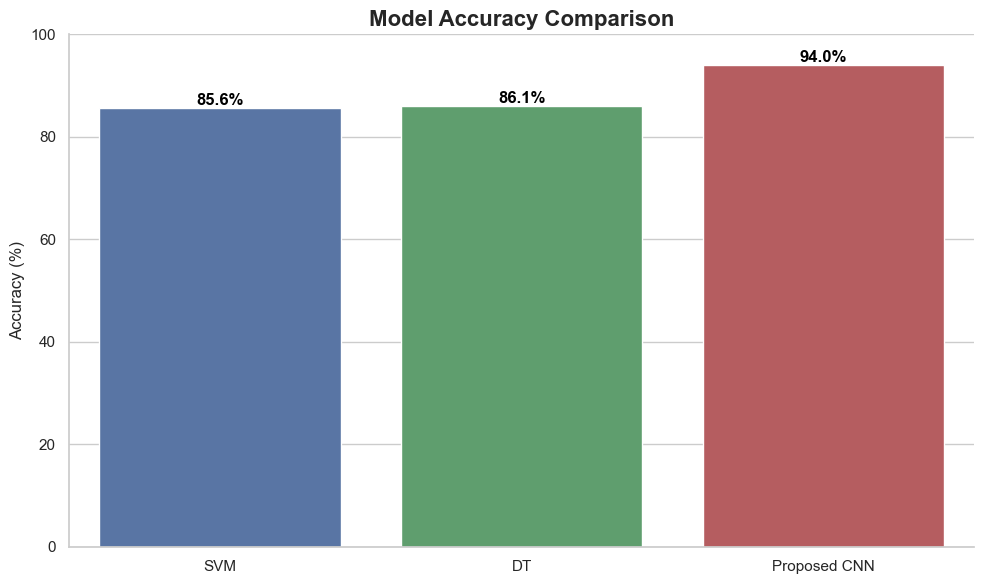

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set(style="whitegrid")

# Model names and accuracy values
models = ['SVM', 'DT', 'Proposed CNN']
accuracies = [85.6, 86.1, 93.99]

# Custom colors for each bar
colors = ['#4C72B0', '#55A868', '#C44E52']

# Create plot
plt.figure(figsize=(10, 6))
bars = sns.barplot(x=models, y=accuracies, palette=colors)

# Annotate each bar with the accuracy value
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.1f}%', 
                  (bar.get_x() + bar.get_width() / 2., height), 
                  ha='center', va='bottom', 
                  fontsize=12, fontweight='bold', color='black')

# Titles and labels
plt.title('Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 100)

# Remove spines for a cleaner look
sns.despine()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


/var/folders/2k/46dv5zj97cb0nhjw799hgpc40000gn/T/ipykernel_7976/4044142876.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=models, y=accuracies, palette=colors)


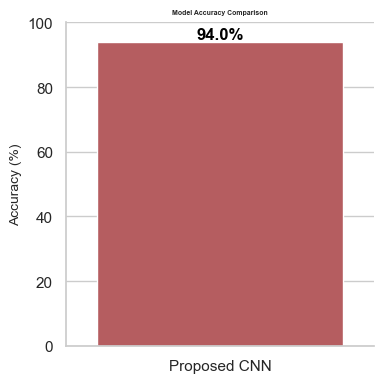

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set(style="whitegrid")

# Model names and accuracy values
models = [ 'Proposed CNN']
accuracies = [ 93.99]

# Custom colors for each bar
colors = ['#C44E52']

# Create plot
plt.figure(figsize=(4, 4))
bars = sns.barplot(x=models, y=accuracies, palette=colors)

# Annotate each bar with the accuracy value
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{height:.1f}%', 
                  (bar.get_x() + bar.get_width() / 2., height), 
                  ha='center', va='bottom', 
                  fontsize=12, fontweight='bold', color='black')

# Titles and labels
plt.title('Model Accuracy Comparison', fontsize=5, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=10)
plt.ylim(0, 100)

# Remove spines for a cleaner look
sns.despine()

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()
